In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import linalg as la
import argparse

import scipy.linalg  as sla

import seaborn as sns
import random

import sys, os
# insert at 1, 0 is the script path (or '' in REPL)
sys.path.insert(1,'../utils' )
from utilssp import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Strategic Prediction Under Competition

Consider the following feature generation process:
$$z_1|\theta=g(\theta)+A_1x_1+A_{-1}x_2+w_1$$
and
$$z_2|\theta=g(\theta)+A_2x_2+A_{-2}x_1+w_2$$
where $\beta\sim \mathcal{D}_{\theta}=\mathcal{N}(0,\sigma_\theta^2 I)$ and $w_i\sim \mathcal{N}(0,\sigma_i^2 I)$. For simplicity we take $$g(\theta)= \theta^\top, \quad B\in \mathbb{R}^{d\times 1}, \ \theta\in \mathbb{R}^{d\times m}$$ 

Each player $i$ seeks to minimize the following loss
$$\begin{align*}
\frac{1}{2}\|z_i-\theta^\top x_i\|^2+\frac{\lambda_i}{2}\|x_i\|^2&=
\frac{1}{2}\|\theta^\top B+A_ix_i+A_{-i}x_{-i}+w_i-\theta^\top x_i\|^2+\frac{\lambda_i}{2}\|x_i\|^2\\
&=\frac{1}{2}(\theta^\top B+A_ix_i+A_{-i}x_{-i}+w_i-\theta^\top x_i)^\top(\theta^\top B+A_ix_i+A_{-i}x_{-i}+w_i-\theta^\top x_i)+\frac{\lambda_i}{2}\|x_i\|^2
\end{align*}
$$

Hence, 
$$\nabla_iL_i=\mathbb{E}_{w_i,\theta}[(A_i-\theta^\top)^\top( \theta^\top B+A_ix_i+A_{-i}x_{-i}+w_i-\theta^\top x_i)+\lambda_ix_i]$$
and the Hessian is 
$$\nabla_i^2L_i=\mathbb{E}_{w_i,\theta}[(A_i-\theta^\top)^\top (A_i-\theta^\top)+\lambda_i I]$$

Social cost
$$\begin{align*}
\sum_{i=1}^2\frac{1}{2}(\theta^\top B+A_ix_i+A_{-i}x_{-i}+w_i-\theta^\top x_i)^\top(\theta^\top B+A_ix_i+A_{-i}x_{-i}+w_i-\theta^\top x_i)+\frac{\lambda_i}{2}\|x_i\|^2
\end{align*}$$

$$\nabla_1S=(A_1-\theta^\top)^\top( \theta^\top B+A_1x_1+A_{-1}x_{-1}+w_1-\theta^\top x_1)+\lambda_1x_1+A_{-2}^\top( \theta^\top B+A_2x_2+A_{-2}x_{1}+w_2-\theta^\top x_2)$$

## Compare AGM with SGM

In [41]:
seeds=random.sample(range(1000), 50)

N=1000
N_test=100
MAXITER=100
sigma_theta=0.01
sigma_w=0.01
sigma_z1=1.1
sigma_z2=1.1

density=0.1
m=10 # both players dimension of z_i
d=2 # size of each players action
B=0*np.ones((d,1)) #np.array([[1],[1]]) #np.random.rand(d,1)
np.random.seed(2)
A1=1*scirand(m,d,density=density).A

Ac1=0.5*scirand(m,d,density=density).A

A2=1*scirand(m,d,density=density).A

Ac2=0.5*scirand(m,d,density=density).A


params={'A1':A1,'A2':A2,'Ac1':Ac1,'Ac2':Ac2} 


lam=[1.0,1.0]
MAXITER=1000
n=2
ddg=ddstrategic_prediction(MAXITER=MAXITER, sigma_theta=0.01,sigma_w=0.01,sigma_z1=0.01,sigma_z2=0.01,density=density,
                       B=B,nu=1e-3, lam=lam,N_test=N_test,n=n, m=m, d=d, params=params,
                           mu_w1=2, mu_w2=1, mu_theta=0)



_,S1,_=la.svd(A1)
_,S2,_=la.svd(A2)
S1=np.sort(S1)[-1]
S2=np.sort(S2)[-1]
eta=0.01 #1/np.max([S1,S2])
eta_agd=0.01 #1/np.max([S1,S2])
nu=1e-2

A1_hat = np.zeros((m,d)) #np.random.rand(m,d)
Ac1_hat =np.zeros((m,d))# np.random.rand(m,d)
A2_hat = np.zeros((m,d)) #np.random.rand(m,d)
Ac2_hat = np.zeros((m,d)) #np.random.rand(m,d)

A_dic={'A1_hats':[A1_hat], 'Ac1_hats': [Ac1_hat],'A2_hats': [A2_hat], 'Ac2_hats': [Ac2_hat] }
mu=2
nu0=1
eta_agd=0.01 #5e-2 #1e-4
all_data={}

mu=2
#nu=0.0001 #0.001 and B=4 #0.0005 B=5 #0.00025 B=5/6
nu0=1 #0.5 #0.1
eta_agd=0.01 #5e-2 #1e-4
for seed in seeds:
    np.random.seed(seed)
    x0=np.random.rand(2,d)
    all_data[seed]={}
    all_data[seed]['x0']=x0

    x_sgd=[x0]
    x_agd=[x0]
    x_rgd=[x0]

    for i in range(MAXITER):
        nu=2*nu0/(len(x_agd)+2*3*d)
        th=1*np.random.normal(0,sigma_theta,size=(d,m))
        z1=ddg.D_w(0)
        z2=ddg.D_w(1)
        x_sgd.append(ddg.proj(x_sgd[-1]-eta*ddg.getgrad(x_sgd[-1],th)))


        x_agd.append(ddg.proj(x_agd[-1]-eta_agd*ddg.getgrad_agd(x_agd[-1],th,A1hat=A_dic['A1_hats'][-1],Ac1hat=A_dic['Ac1_hats'][-1],
                                                            A2hat=A_dic['A2_hats'][-1], Ac2hat=A_dic['Ac2_hats'][-1], passvals=True)))
        A1_hat,Ac1_hat,A2_hat,Ac2_hat = ddg.update_estimate(x_agd[-1], z1, z2,th,nu=nu,mu=mu, A1hat=A_dic['A1_hats'][-1],Ac1hat=A_dic['Ac1_hats'][-1],
                                                            A2hat=A_dic['A2_hats'][-1], Ac2hat=A_dic['Ac2_hats'][-1], passvals=True,UNCORR=False)
        # print('x_agd:',x_agd[-1])

        A_dic['A1_hats'].append(A1_hat)
        A_dic['Ac1_hats'].append(Ac1_hat)
        A_dic['A2_hats'].append(A2_hat)
        A_dic['Ac2_hats'].append(Ac2_hat)

        z1 = ddg.D_w(0)+ddg.A1@(x_rgd[-1][0])+ddg.Ac1@(x_rgd[-1][1])+th.T@ddg.B.flatten()
        z2 = ddg.D_w(1)+ddg.A2@(x_rgd[-1][0])+ddg.Ac2@(x_rgd[-1][0])+th.T@ddg.B.flatten()

        x_rgd.append(ddg.proj(x_rgd[-1]-eta*ddg.getgrad_rgd(x_rgd[-1],z1,z2, th)))

    x_sgd=np.asarray(x_sgd)
    x_agd=np.asarray(x_agd)
    x_rgd=np.asarray(x_rgd)
    nash=[]

    for i in range(n):
        nash.append(np.mean(x_sgd[-100:,i,:],axis=0)) #np.mean(x_rgd_ps[-1000:,:,i],axis=0
    nash=np.asarray(nash)
    #print(nash)

    error_sgd=[]
    error_agd=[]
    error_rgd=[]
    for x,y,z in zip(x_sgd,x_agd,x_rgd):
        error_sgd.append(la.norm(x-nash)**2)
        error_agd.append(la.norm(y-nash)**2)
        error_rgd.append(la.norm(z-nash)**2)

    err_agd=np.asarray(error_agd)
    err_sgd=np.asarray(error_sgd)#
    err_rgd=np.asarray(error_rgd)

    all_data[seed]['error_agd']=err_agd
    all_data[seed]['error_sgd']=err_sgd
    all_data[seed]['error_rgd']=err_rgd

(1001,)


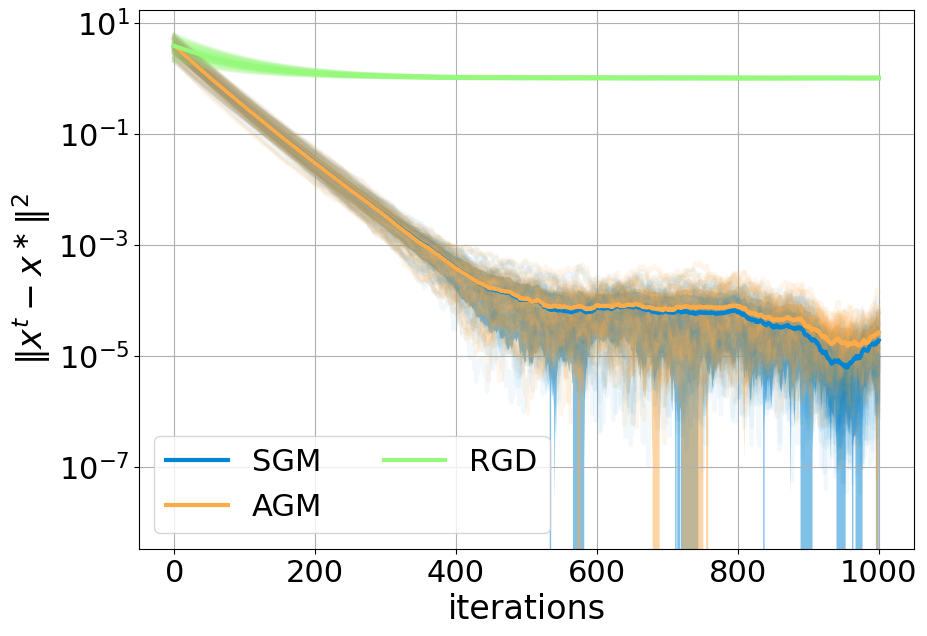

In [35]:
## Generate Plots Gap to Nash
filename='./figs/convergence_final.'
SAVE=0

errs_agd=[]
errs_sgd=[]
errs_dfo=[]
errs_rgd=[]
fs=24
for seed in seeds:
    errs_agd.append(all_data[seed]['error_agd'])
    errs_sgd.append(all_data[seed]['error_sgd'])
    errs_rgd.append(all_data[seed]['error_rgd'])

errs_agd=np.asarray(errs_agd)
errs_sgd=np.asarray(errs_sgd)
errs_rgd=np.asarray(errs_rgd)


errs_agd_mean=np.mean(errs_agd,axis=0)
errs_sgd_mean=np.mean(errs_sgd,axis=0)
errs_rgd_mean=np.mean(errs_rgd,axis=0)

errs_agd_var=np.std(errs_agd,axis=0)
errs_sgd_var=np.std(errs_sgd,axis=0)
errs_rgd_var=np.std(errs_rgd,axis=0)
print(np.shape(errs_agd_var))

iterations=np.arange(0,MAXITER+1)
fig=plt.figure(figsize=(10,7))
for i in range(len(errs_agd)):
    plt.plot(errs_sgd[i,:], linewidth=3,color='xkcd:cerulean', alpha=0.05)
    plt.plot(errs_agd[i,:], linewidth=3, alpha=0.1, color='xkcd:light orange')
    plt.plot(errs_rgd[i,:], linewidth=3, alpha=0.1, color='xkcd:light green')
    

plt.plot(errs_sgd_mean, linewidth=3,color='xkcd:cerulean', label='SGM')
plt.fill_between(iterations,errs_sgd_mean+errs_sgd_var,errs_sgd_mean-errs_sgd_var, alpha=0.5, linewidth=0,color='xkcd:cerulean')
plt.plot(errs_agd_mean, linewidth=3, color='xkcd:light orange', label='AGM')
plt.yscale('log')
plt.fill_between(iterations,errs_agd_mean+errs_agd_var,errs_agd_mean-errs_agd_var, alpha=0.5, linewidth=0, color='xkcd:light orange')
plt.plot(errs_rgd_mean, linewidth=3, color='xkcd:light green', label='RGD')
plt.fill_between(iterations,errs_rgd_mean+errs_rgd_var,errs_rgd_mean-errs_rgd_var, alpha=0.5, linewidth=0, color='xkcd:light green')
plt.grid(True)

plt.tick_params(labelsize=fs-2)
plt.ylabel(r'$\Vert x^t-x^\ast\Vert^2$', fontsize=fs)
plt.xlabel(r'iterations', fontsize=fs)
plt.legend(fontsize=fs-2, loc='lower left',ncol=2)
if SAVE:
    for tag in ['pdf','png']:
        plt.savefig(filename+tag,  bbox_inches='tight', dpi=300)

## Convergence of Repeated Stochastic Gradient Method

In [36]:
B=0*np.ones((d,1))
lam=[1.0,1.0]
maxx=10
n=2
N_test=100
NUM=100
seeds=random.sample(range(1000), 100)
all_data={}
d=5
m=100
x0=np.random.rand(2,d)

A1=scirand(m,d,density=density).A

Ac1=0.5*scirand(m,d,density=density).A

A2=scirand(m,d,density=density).A

Ac2=0.5*scirand(m,d,density=density).A

B=20*np.ones((d,1)) #np.array([[1],[1]]) #np.random.rand(d,1)

params={'A1':A1,'A2':A2,'Ac1':Ac1,'Ac2':Ac2} 
MAXITER=5000
ddg=ddstrategic_prediction(MAXITER=MAXITER, sigma_theta=0.01,sigma_w=0.01,sigma_z1=0.01,sigma_z2=0.01,density=density,
                       B=B,nu=1e-3, lam=lam, maxx=maxx, n=n, N_test=N_test, seed=seed, m=m, d=d, params=params,
                           mu_w1=0, mu_w2=0, mu_theta=10)

## Get PS Eq
np.random.seed(10)
x0=np.random.rand(2,d)
x_rgd=[x0]
MAXITER=10000
ddg=ddstrategic_prediction(MAXITER=MAXITER, sigma_theta=0.01,sigma_w=0.01,sigma_z1=0.01,sigma_z2=0.01,density=density,
                       B=B,nu=1e-3, lam=lam, maxx=maxx, n=n, N_test=N_test, seed=seed, m=m, d=d, params=params,
                           mu_w1=0, mu_w2=0, mu_theta=10)
for i in range(MAXITER):
    th=np.random.normal(0,sigma_theta,size=(d,m))
    z1 = ddg.D_w(0)+ddg.A1@(x_rgd[-1][0])+ddg.Ac1@(x_rgd[-1][1])+th.T@ddg.B.flatten()
    z2 = ddg.D_w(1)+ddg.A2@(x_rgd[-1][0])+ddg.Ac2@(x_rgd[-1][0])+th.T@ddg.B.flatten()

    x_rgd.append(ddg.proj(x_rgd[-1]-eta*ddg.getgrad_rgd(x_rgd[-1],z1,z2, th)))


x_rgd=np.asarray(x_rgd)

error_rgd=[]

ps=[]
for i in range(n):
    ps.append(np.mean(x_rgd[-100:,i,:],axis=0))

ps=np.asarray(ps)

print(ps)
print(ddg.getgrad_rgd(ps,z1,z2,th))

[[0.19437086 0.19667673 0.19294267 0.1999814  0.19592916]
 [0.19421961 0.19637124 0.19368922 0.19958083 0.19610023]]
[[-0.00202722  0.04963391  0.03015474 -0.0293559  -0.01706053]
 [ 0.0051295   0.06783557  0.03004731 -0.00844905 -0.02299008]]


In [37]:
# Set Initial Condition 
np.random.rand(2)
x0=np.random.rand(2,d)

MAXITER=1000

eta=0.1 

#run for a bunch of random seeds
seeds=random.sample(range(0,200), 10)
all_data={}
for seed in seeds:
    x0=np.random.rand(2,d)
    x_rgd=[x0]

    for i in range(MAXITER):
        th=np.random.normal(0,sigma_theta,size=(d,m))
        z1 = ddg.D_w(0)+ddg.A1@(x_rgd[-1][0])+ddg.Ac1@(x_rgd[-1][1])+th.T@ddg.B.flatten()
        z2 = ddg.D_w(1)+ddg.A2@(x_rgd[-1][0])+ddg.Ac2@(x_rgd[-1][0])+th.T@ddg.B.flatten()

        x_rgd.append(ddg.proj(x_rgd[-1]-eta*ddg.getgrad_rgd(x_rgd[-1],z1,z2, th)))


    x_rgd=np.asarray(x_rgd)
    all_data[seed]={}
    all_data[seed]['x_rgd']=x_rgd
    error_rgd=[]

    for x in x_rgd:
        error_rgd.append(la.norm(x-ps)**2)
        
    err_rgd=np.asarray(error_rgd)

    all_data[seed]['error_rgd']=err_rgd



#### Plot things

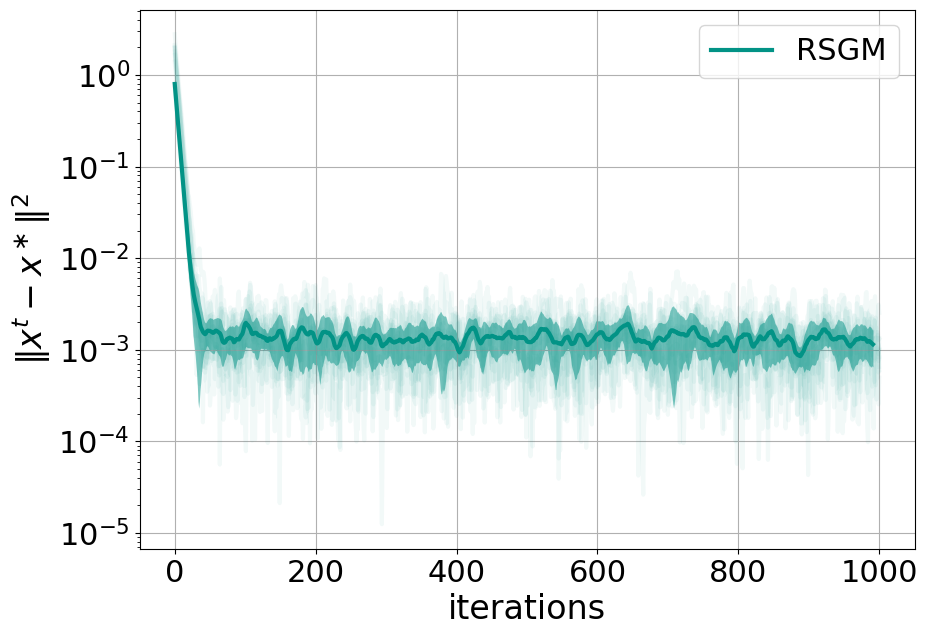

In [38]:
SAVE=0
filename='./figs/convergence_synthetic_rgd.'
fs=24
errs_rgd=[]
errs_rgd_=[]
errs_sgd=[]

fs=24
for seed in seeds:
    errs_rgd_.append(running_mean(all_data[seed]['error_rgd'],10)) 
    errs_rgd.append(all_data[seed]['error_rgd'])

errs_rgd=np.asarray(errs_rgd)
errs_rgd_=np.asarray(errs_rgd_)

errs_rgd_mean=np.mean(errs_rgd_,axis=0)

errs_rgd_var=np.std(errs_rgd_,axis=0)

iterations=np.arange(0,len(errs_rgd_var)) #MAXITER+1)
fig=plt.figure(figsize=(10,7))
for i in range(len(errs_rgd)):
    plt.plot(errs_rgd[i,:], linewidth=3,color='xkcd:teal', alpha=0.05)

plt.plot(errs_rgd_mean, linewidth=3,color='xkcd:teal', label='RSGM')
plt.fill_between(iterations,errs_rgd_mean+errs_rgd_var,errs_rgd_mean-errs_rgd_var, alpha=0.5, linewidth=0,color='xkcd:teal')

plt.yscale('log')
plt.grid(True)

plt.tick_params(labelsize=fs-2)
plt.ylabel(r'$\Vert x^t-x^\ast\Vert^2$', fontsize=fs)
plt.xlabel(r'iterations', fontsize=fs)
plt.legend(fontsize=fs-2, loc='upper right',ncol=2)
if SAVE:
    for tag in ['pdf','png']:
        plt.savefig(filename+tag,  bbox_inches='tight', dpi=300)

## Compute PoA

In [ ]:

np.random.rand(seed)
x0=np.random.rand(2,d)


## Find PS

MAXITER=5000
print()
MAXITER=5000
eta=1 #1/np.max([S1,S2])
print(eta)

print(x0)
lam1=1
lam2=1

all_data={}
#for seed in seeds:
np.random.rand(2)
x0=np.random.rand(2,d)
for seed,m in enumerate(range(2,100,10)):
    
    A1=scirand(m,d,density=density).A

    Ac1=0.5*scirand(m,d,density=density).A

    A2=scirand(m,d,density=density).A

    Ac2=0.5*scirand(m,d,density=density).A

    B=0*np.ones((d,1)) #np.array([[1],[1]]) #np.random.rand(d,1)

    params={'A1':A1,'A2':A2,'Ac1':Ac1,'Ac2':Ac2} 

    ddg=ddstrategic_prediction(MAXITER=MAXITER, sigma_theta=0.01,sigma_w=0.01,sigma_z1=0.01,sigma_z2=0.01,density=density,
                           B=B,nu=1e-3, lam=lam, maxx=maxx, n=n, N_test=N_test, seed=seed, m=m, d=d, params=params,
                               mu_w1=0, mu_w2=0, mu_theta=10)
    x_ps=[x0]
    x_so=[x0]
    x_ne=[x0]
    for i in range(MAXITER):
        th=np.random.normal(0,sigma_theta,size=(d,m))
        z1 = ddg.D_w(0)+ddg.A1@(x_ps[-1][0])+ddg.Ac1@(x_ps[-1][1])+th.T@ddg.B.flatten()
        z2 = ddg.D_w(1)+ddg.A2@(x_ps[-1][0])+ddg.Ac2@(x_ps[-1][0])+th.T@ddg.B.flatten()

        x_ps.append(ddg.proj(x_ps[-1]-eta*ddg.getgrad_rgd(x_ps[-1],z1,z2, th)))
        x_ne.append(ddg.proj(x_ne[-1]-eta*ddg.getgrad(x_ne[-1],th)))
        x_so.append(ddg.proj(x_so[-1]-eta*ddg.getgrad_so(x_so[-1],th)))

    x_ps=np.asarray(x_ps)
    x_ne=np.asarray(x_ne)
    x_so=np.asarray(x_so)
    all_data[seed]={}

    ne=[]
    so=[]
    ps=[]
    for i in range(n):
        ne.append(np.mean(x_ne[-100:,i,:],axis=0)) #np.mean(x_rgd_ps[-1000:,:,i],axis=0
        so.append(np.mean(x_so[-100:,i,:],axis=0))
        ps.append(np.mean(x_ps[-100:,i,:],axis=0))

    ne=np.asarray(ne)
    so=np.asarray(so)
    ps=np.asarray(ps)

    sc_so=[]
    sc_ne=[]
    sc_ps=[]
    for i in range(NUM):
        th=np.random.normal(0,sigma_theta,size=(d,m))
        sc_so.append(sum(ddg.get_loss(so,ddg.D_w(0),ddg.D_w(1),th))/NUM)
        sc_ne.append(sum(ddg.get_loss(ne,ddg.D_w(0),ddg.D_w(1),th))/NUM)
        sc_ps.append(sum(ddg.get_loss(ps,ddg.D_w(0),ddg.D_w(1),th))/NUM)

    sc_so=np.asarray(sum(sc_so))
    sc_ne=np.asarray(sum(sc_ne))
    sc_ps=np.asarray(sum(sc_ps))

    all_data[seed]={}
    all_data[seed]['ne']=ne
    all_data[seed]['ps']=ps
    all_data[seed]['so']=so
    all_data[seed]['x_nash']=x_sgd
    print()
    print("-------------")
    print("seed: ", seed)
    #print("ne cond: ", ddg.getgrad(ne,th))
    #print("ps cond: ", ddg.getgrad_rgd(ps,z1,z2,th))
    #print("so cond: ", ddg.getgrad_so(so,th))
    all_data[seed]['x_ps']=x_rgd
    all_data[seed]['x_so']=x_so
    all_data[seed]['sc_so']=sc_so
    all_data[seed]['sc_ne']=sc_ne
    all_data[seed]['sc_ps']=sc_ps
    print("poa(ps) : ", all_data[seed]['sc_ps']/all_data[seed]['sc_so'])
    print("poa(ne) : ", all_data[seed]['sc_ne']/all_data[seed]['sc_so'])


1
[[0.92170278 0.37220476 0.59635775 0.79349262 0.30262381]
 [0.47820854 0.4382622  0.83701719 0.46221414 0.95971645]]

-------------
seed:  0
poa(ps) :  0.38623467938174455
poa(ne) :  1.700676855783585

-------------
seed:  1
poa(ps) :  0.05435653870110745
poa(ne) :  0.9617499591589358

-------------
seed:  2
poa(ps) :  0.05255558459867238
poa(ne) :  1.4374710245766793

-------------
seed:  3
poa(ps) :  1.0300963512813854
poa(ne) :  8.821949177005997

-------------
seed:  4
poa(ps) :  0.1250498215040409
poa(ne) :  2.5761873442249805

-------------
seed:  5
poa(ps) :  1.0048844774040908
poa(ne) :  11.681486547546095

-------------
seed:  6
poa(ps) :  1.0667397656441577
poa(ne) :  0.9988111626796747

-------------
seed:  7
poa(ps) :  1.0053437177909899
poa(ne) :  0.9634650219373452

-------------
seed:  8
poa(ps) :  1.0187208269677175
poa(ne) :  0.9712470081148427

-------------
seed:  9
poa(ps) :  1.0407550089963022
poa(ne) :  1.0064058275713184
